# CDMA Cell Phone Radiation — Pathology Risk Analysis (B6C3F1 Mice)

**Study:** NTP TR-596 — Toxicology and Carcinogenesis Studies of Cell Phone Radiofrequency Radiation (CDMA)  
**Source:** CEBS accession 3801_7866 (TDMS 2010575)

**Key question:** Do irradiated mice develop neoplasms at a greater rate, or is the apparent increase confounded by longer survival in the irradiated groups?

**Approach:**
1. Kaplan-Meier survival curves by treatment group (males + females pooled)
2. For each pathology finding, logistic regression testing dose effect on risk:
   - **Model 1:** Unadjusted (dose only)
   - **Model 2:** Adjusted for sex
   - **Model 3:** Adjusted for sex + days on study (age at necropsy) — addresses survival confounding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import statsmodels.api as sm
import warnings
import seaborn as sns 
warnings.filterwarnings("ignore")

DATA = Path("../data/TR-596_Technical_Report_Pathology_Tables_and_Curves")

def load_xls(filename):
    """Load HTML-formatted .xls files from CEBS."""
    tables = pd.read_html(DATA / filename)
    return tables[0], tables[1]

# ── Load survival data ──
_, surv_f = load_xls("2010575_Female_Individual_Animal_Survival_Data.xls")
_, surv_m = load_xls("2010575_Male_Individual_Animal_Survival_Data.xls")
surv_f["Sex"] = "Female"
surv_m["Sex"] = "Male"
surv = pd.concat([surv_f, surv_m], ignore_index=True)

# Standardize treatment to numeric dose (W/kg)
dose_map = {"Vehicle Control": 0, "2.5": 2.5, "5": 5, "10": 10}
surv["Dose"] = surv["Treatment"].map(dose_map)
surv["Dose_Label"] = surv["Treatment"].replace({"Vehicle Control": "0 (Control)"})

# Event indicator: died before terminal sacrifice
surv["event"] = (~surv["Removal Reason"].isin(["Terminal Sacrifice", "Scheduled Sacrifice"])).astype(int)

print(f"Total animals: {len(surv)} (Female: {(surv.Sex=='Female').sum()}, Male: {(surv.Sex=='Male').sum()})")
print(f"\nAnimals per treatment group:")
display(surv.groupby("Dose_Label").agg(n=("Animal Number","count"), events=("event","sum"), 
                                        median_days=("Days on Study","median")).reset_index())

Total animals: 840 (Female: 419, Male: 421)

Animals per treatment group:


,Dose_Label,n,events,median_days
0,0 (Control),210,48,732.0
1,10,210,38,733.0
2,2.5,210,25,736.0
3,5,210,40,732.5


## 1. Kaplan-Meier Survival Curves by Treatment Group (Pooled Sexes)

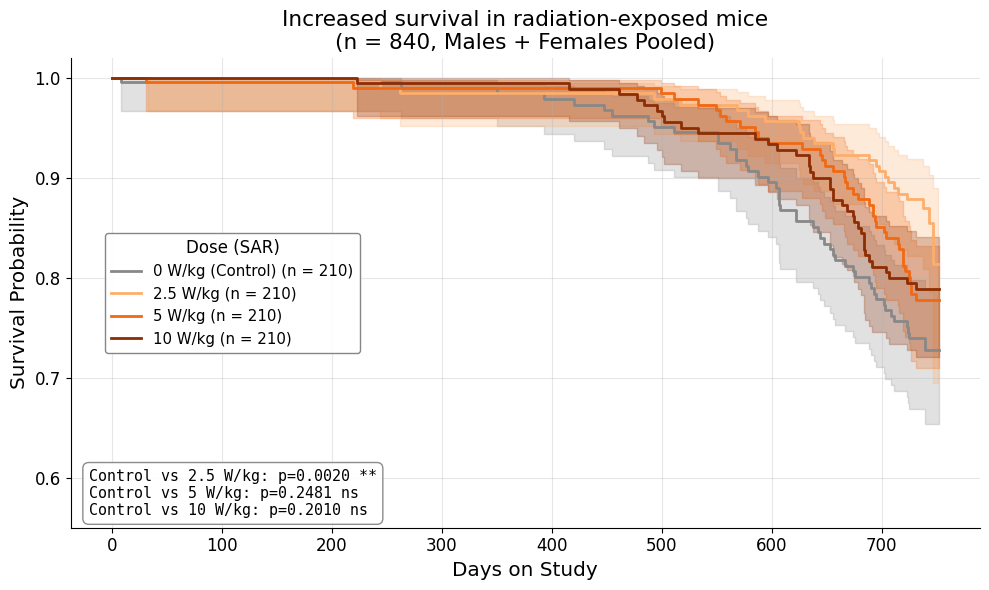

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: "#888888", 2.5: "#FDAE6B", 5: "#F16913", 10: "#8C2D04"}
labels = {0: "0 W/kg (Control)", 2.5: "2.5 W/kg", 5: "5 W/kg", 10: "10 W/kg"}

kmf_fits = {}
for dose in [0, 2.5, 5, 10]:
    group = surv[surv["Dose"] == dose]
    kmf = KaplanMeierFitter()
    kmf.fit(group["Days on Study"], group["event"], label=f"{labels[dose]} (n = 210)")
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[dose], linewidth=2)
    kmf_fits[dose] = kmf

# Log-rank pairwise tests
pairwise = {}
doses = [0, 2.5, 5, 10]
for i, d1 in enumerate(doses):
    for d2 in doses[i+1:]:
        g1 = surv[surv.Dose == d1]
        g2 = surv[surv.Dose == d2]
        result = logrank_test(g1["Days on Study"], g2["Days on Study"], g1["event"], g2["event"])
        pairwise[(d1, d2)] = result.p_value

def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

pval_lines = []
for d1, d2 in [(0, 2.5), (0, 5), (0, 10)]:
    p = pairwise[(d1, d2)]
    star = sig_label(p)
    pval_lines.append(f"Control vs {d2} W/kg: p={p:.4f} {star}")
pval_text = "\n".join(pval_lines)

ax.text(0.02, 0.02, pval_text, transform=ax.transAxes, fontsize=10.8,
        verticalalignment="bottom", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9))

ax.set_title("Increased survival in radiation-exposed mice\n(n = 840, Males + Females Pooled)", fontsize=15.6)
ax.set_xlabel("Days on Study", fontsize=14.4)
ax.set_ylabel("Survival Probability", fontsize=14.4)
ax.tick_params(axis='both', labelsize=12)
leg = ax.legend(title="Dose (SAR)", loc="center left", bbox_to_anchor=(0.03, 0.5), framealpha=0.95, edgecolor="gray", fontsize=10.8, title_fontsize=12)
ax.set_ylim(0.55, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()

## 1b. Hazard Ratios — Pairwise and Dose Trend (Cox Proportional Hazards)

The hazard ratio (HR) from a Cox model quantifies the relative risk of death at any given time point. HR < 1 means the group has lower mortality risk (lives longer); HR = 0.5 means half the instantaneous death risk.

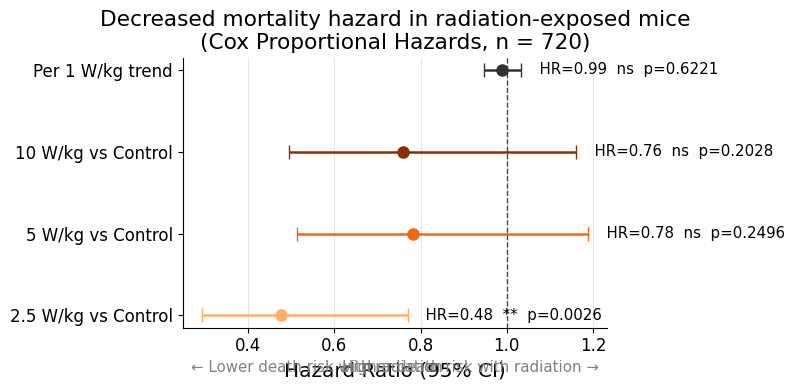

In [3]:
from lifelines import CoxPHFitter

surv_cox = surv[surv["Removal Reason"] != "Scheduled Sacrifice"].copy()
doses = [0, 2.5, 5, 10]
dose_colors = {0: "#888888", 2.5: "#FDAE6B", 5: "#F16913", 10: "#8C2D04"}
dose_labels = {0: "0 (Control)", 2.5: "2.5 W/kg", 5: "5 W/kg", 10: "10 W/kg"}

# Pairwise HRs vs control
rows = []
for d2 in [2.5, 5, 10]:
    pair = surv_cox[surv_cox.Dose.isin([0, d2])].copy()
    pair["exposed"] = (pair["Dose"] == d2).astype(int)
    cph = CoxPHFitter()
    cph.fit(pair[["Days on Study", "event", "exposed"]], duration_col="Days on Study", event_col="event")
    hr = np.exp(cph.params_["exposed"])
    ci = np.exp(cph.confidence_intervals_.values[0])
    p = cph.summary["p"]["exposed"]
    rows.append({"label": f"{d2} W/kg vs Control", "hr": hr, "lo": ci[0], "hi": ci[1], "p": p,
                 "color": dose_colors[d2]})

# Dose trend
cph_trend = CoxPHFitter()
cph_trend.fit(surv_cox[["Days on Study", "event", "Dose"]], duration_col="Days on Study", event_col="event")
hr_t = np.exp(cph_trend.params_["Dose"])
ci_t = np.exp(cph_trend.confidence_intervals_.values[0])
p_t = cph_trend.summary["p"]["Dose"]
rows.append({"label": "Per 1 W/kg trend", "hr": hr_t, "lo": ci_t[0], "hi": ci_t[1], "p": p_t,
             "color": "#333333"})

fig, ax = plt.subplots(figsize=(8, 4))
for i, r in enumerate(rows):
    ax.errorbar(r["hr"], i, xerr=[[r["hr"] - r["lo"]], [r["hi"] - r["hr"]]], fmt="o",
                color=r["color"], markersize=8, capsize=5, linewidth=1.8, zorder=3)
    star = "***" if r["p"] < 0.001 else "**" if r["p"] < 0.01 else "*" if r["p"] < 0.05 else "ns"
    ax.text(r["hi"] + 0.02, i, f'  HR={r["hr"]:.2f}  {star}  p={r["p"]:.4f}', va="center", fontsize=10.8)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r["label"] for r in rows], fontsize=12)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=14.4)
ax.set_title("Decreased mortality hazard in radiation-exposed mice\n(Cox Proportional Hazards, n = 720)", fontsize=15.6)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.3)
ax.text(0.02, -0.12, "← Lower death risk with radiation", transform=ax.transAxes, ha="left", va="top", fontsize=10.8, color="gray")
ax.text(0.98, -0.12, "Higher death risk with radiation →", transform=ax.transAxes, ha="right", va="top", fontsize=10.8, color="gray")
plt.tight_layout()
sns.despine()
plt.show()

## 2. Load Pathology Data & Build Per-Animal Pathology Indicators

Each pathology file lists only animals that **had** a given lesion. We merge with the full survival roster to create binary indicators (1 = pathology present, 0 = not found) for every animal.

In [4]:
# ── Load pathology data ──
def load_pathology(filename, sex):
    _, df = load_xls(filename)
    df["Sex"] = sex
    return df

neo_f = load_pathology("2010575_Female_Individual_Animal_Neoplastic_Pathology_Data.xls", "Female")
neo_m = load_pathology("2010575_Male_Individual_Animal_Neoplastic_Pathology_Data.xls", "Male")
non_f = load_pathology("2010575_Female_Individual_Animal_Non_Neoplastic_Pathology_Data.xls", "Female")
non_m = load_pathology("2010575_Male_Individual_Animal_Non_Neoplastic_Pathology_Data.xls", "Male")

neo = pd.concat([neo_f, neo_m], ignore_index=True)
non = pd.concat([non_f, non_m], ignore_index=True)

# Create pathology key: Organ - Lesion Name
neo["Pathology"] = neo["Organ"] + " — " + neo["Lesion Name"]
non["Pathology"] = non["Organ"] + " — " + non["Lesion Name"]
neo["Type"] = "Neoplastic"
non["Type"] = "Non-Neoplastic"

path_all = pd.concat([neo, non], ignore_index=True)

# Map treatment to dose
path_all["Dose"] = path_all["Treatment Group"].map(dose_map)

# Get unique animals with each pathology
path_animals = (
    path_all.groupby(["Pathology", "Type", "Animal Number", "Sex"])
    .size()
    .reset_index(name="count")
)

print(f"Neoplastic pathology types: {neo['Pathology'].nunique()}")
print(f"Non-neoplastic pathology types: {non['Pathology'].nunique()}")
print(f"Total pathology records: {len(path_all)}")

# ── Exclude scheduled-sacrifice animals (interim sacrifice at week 14) ──
# These animals were sacrificed early by design, not due to health — they bias the analysis
scheduled = surv[surv["Removal Reason"] == "Scheduled Sacrifice"]["Animal Number"].unique()
surv_main = surv[surv["Removal Reason"] != "Scheduled Sacrifice"].copy()
print(f"\nExcluding {len(scheduled)} scheduled-sacrifice animals. Remaining: {len(surv_main)}")

Neoplastic pathology types: 222
Non-neoplastic pathology types: 218
Total pathology records: 8464

Excluding 120 scheduled-sacrifice animals. Remaining: 720


## 3. Logistic Regression: Dose Effect on Each Pathology

For each pathology with ≥15 affected animals, we fit three logistic regression models:

| Model | Formula | Purpose |
|-------|---------|---------|
| 1 | `pathology ~ Dose` | Unadjusted dose-response |
| 2 | `pathology ~ Dose + Sex` | Adjusted for sex |
| 3 | `pathology ~ Dose + Sex + Days_on_Study` | Adjusted for sex + survival time |

Model 3 directly addresses the confounding question: if dose is only significant in Models 1–2 but not Model 3, the effect is explained by differential survival rather than a direct radiation effect.

Dose is treated as a continuous variable (0, 2.5, 5, 10 W/kg) to test for a linear dose-response trend. The coefficient represents the change in log-odds per 1 W/kg increase.

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.plots import run_pathology_regression, format_results, plot_forest, plot_prevalence_bars

DOSE_VALS = [0, 2.5, 5, 10]
DOSE_COLORS = ["#888888", "#FDAE6B", "#F16913", "#8C2D04"]
DOSE_BAR_LABELS = ["0 (Control)", "2.5 W/kg", "5 W/kg", "10 W/kg"]

In [6]:
# ── Run for all pathologies with ≥15 affected animals ──
MIN_AFFECTED = 15
path_counts = path_all.groupby(["Pathology", "Type"])["Animal Number"].nunique().reset_index(name="n_affected")
path_eligible = path_counts[path_counts["n_affected"] >= MIN_AFFECTED]

print(f"Pathologies with ≥{MIN_AFFECTED} affected animals: {len(path_eligible)} "
      f"({(path_eligible.Type=='Neoplastic').sum()} neoplastic, {(path_eligible.Type=='Non-Neoplastic').sum()} non-neoplastic)")

all_results = []
for _, row in path_eligible.iterrows():
    res = run_pathology_regression(row["Pathology"], row["Type"], surv_main, path_all, DOSE_VALS)
    if res:
        all_results.append(res)

results_df = pd.DataFrame(all_results)
print(f"Successfully modeled: {len(results_df)} pathologies")

Pathologies with ≥15 affected animals: 70 (17 neoplastic, 53 non-neoplastic)


Successfully modeled: 65 pathologies


## 4. Results — Neoplastic Pathologies

Sorted by Model 1 (unadjusted) p-value. Key columns:
- **OR** = Odds Ratio per 1 W/kg increase in dose
- **p** = p-value for the dose coefficient
- Compare M1 vs M3: if M1 is significant but M3 is not, the effect is likely confounded by survival

In [7]:
neo_results = format_results(results_df, "Neoplastic")
print(f"Neoplastic pathologies analyzed: {len(neo_results)}")
display(neo_results.style.apply(
    lambda row: ["background: #ffffcc" if row["M1: p"] < 0.05 else "" for _ in row], axis=1
).format(precision=4))

Neoplastic pathologies analyzed: 17


,Pathology,N,Prev%,M1: OR,M1: p,M2: OR,M2: p,M3: OR,M3: p,M3: Days OR,M3: Days p
0,Ovary — Cystadenoma,16,2.2000,1.1180,0.0940,1.1210,0.0917,1.1190,0.0985,1.0070,0.3493
1,Pituitary Gland — Adenoma,25,3.5000,0.9070,0.1107,0.9040,0.1053,0.9000,0.0933,1.0057,0.2668
2,Spleen — Histiocytic Sarcoma,19,2.6000,1.0970,0.1307,1.0970,0.1300,1.1040,0.1086,0.9959,0.0094
3,Kidney — Lymphoma Malignant,18,2.5000,0.9410,0.3774,0.9410,0.3739,0.9440,0.3992,0.9974,0.1519
4,Liver — Hepatocellular Adenoma,320,44.4000,1.0120,0.5429,1.0150,0.4923,1.0120,0.5999,1.0093,0.0000
5,Harderian Gland — Adenoma,42,5.8000,0.9740,0.5547,0.9740,0.5536,0.9710,0.5058,1.0214,0.0575
6,Liver — Lymphoma Malignant,15,2.1000,0.9590,0.5674,0.9580,0.5639,0.9630,0.6094,0.9964,0.0352
7,Liver — Histiocytic Sarcoma,18,2.5000,0.9630,0.5730,0.9620,0.5683,0.9680,0.6319,0.9955,0.0028
8,Liver — Hepatocellular Carcinoma,125,17.4000,1.0150,0.5832,1.0160,0.5587,1.0150,0.5858,1.0017,0.2579
9,Liver — Hepatoblastoma,36,5.0000,1.0160,0.7288,1.0170,0.7160,1.0190,0.6973,1.0166,0.1021


## 5. Results — Non-Neoplastic Pathologies

In [8]:
non_results = format_results(results_df, "Non-Neoplastic")
print(f"Non-neoplastic pathologies analyzed: {len(non_results)}")
display(non_results.style.apply(
    lambda row: ["background: #ffffcc" if row["M1: p"] < 0.05 else "" for _ in row], axis=1
).format(precision=4))

Non-neoplastic pathologies analyzed: 48


,Pathology,N,Prev%,M1: OR,M1: p,M2: OR,M2: p,M3: OR,M3: p,M3: Days OR,M3: Days p
0,Bone — Fibro-Osseous Lesion,15,2.1000,0.7890,0.0186,0.7860,0.0178,0.7760,0.0150,1.0092,0.2686
1,Seminal Vesicle — Dilation,105,14.6000,0.9340,0.0243,0.9220,0.0141,0.9200,0.0122,1.0023,0.1859
2,Kidney — Infiltration Cellular,421,58.5000,0.9560,0.0292,0.9560,0.0280,0.9500,0.0149,1.0072,0.0000
3,Lymph Node — Hyperplasia,87,12.1000,1.0640,0.0397,1.0650,0.0392,1.0650,0.0439,1.0303,0.0045
4,Urinary Bladder — Infiltration Cellular,400,55.6000,1.0410,0.0484,1.0470,0.0368,1.0450,0.0464,1.0068,0.0000
5,Thymus — Cyst,82,11.4000,1.0590,0.0635,1.0630,0.0561,1.0660,0.0513,1.0186,0.0091
6,Thyroid Gland — Infiltration Cellular,16,2.2000,1.1180,0.0940,1.1190,0.0930,1.1180,0.1007,1.0140,0.2544
7,Liver — Inflammation,16,2.2000,0.8730,0.0956,0.8730,0.0955,0.8750,0.0995,0.9989,0.6527
8,Brain — Mineral,626,86.9000,0.9560,0.1263,0.9560,0.1262,0.9480,0.0733,1.0055,0.0000
9,Thymus — Atrophy,41,5.7000,0.9330,0.1376,0.9330,0.1371,0.9420,0.2024,0.9950,0.0000


## 6. Summary: Confounding Analysis

How many pathologies show a significant dose effect (p < 0.05) in each model?  
If the count drops substantially from M1 → M3, survival confounding is a major factor.

In [9]:
summary = []
for ptype in ["Neoplastic", "Non-Neoplastic"]:
    subset = results_df[results_df["type"] == ptype]
    summary.append({
        "Type": ptype,
        "Total Analyzed": len(subset),
        "M1 sig (p<0.05)": (subset["m1_dose_p"] < 0.05).sum(),
        "M2 sig (p<0.05)": (subset["m2_dose_p"] < 0.05).sum(),
        "M3 sig (p<0.05)": (subset["m3_dose_p"] < 0.05).sum(),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

# Show pathologies where M1 is significant but M3 is NOT — evidence of survival confounding
confounded = results_df[(results_df["m1_dose_p"] < 0.05) & (results_df["m3_dose_p"] >= 0.05)]
persistent = results_df[(results_df["m1_dose_p"] < 0.05) & (results_df["m3_dose_p"] < 0.05)]

print(f"\n{'='*80}")
print(f"Pathologies where dose is significant UNADJUSTED but NOT after age adjustment")
print(f"(i.e., confounded by survival): {len(confounded)}")
print(f"{'='*80}")
if len(confounded) > 0:
    for _, row in confounded.sort_values("m1_dose_p").iterrows():
        direction = "↑" if row["m1_dose_or"] > 1 else "↓"
        print(f"  {direction} {row['type']:15s} | {row['pathology']:45s} | M1 OR={row['m1_dose_or']:.3f} p={row['m1_dose_p']:.4f} → M3 OR={row['m3_dose_or']:.3f} p={row['m3_dose_p']:.4f}")

print(f"\n{'='*80}")
print(f"Pathologies where dose remains significant AFTER age adjustment")
print(f"(i.e., likely a real radiation effect): {len(persistent)}")
print(f"{'='*80}")
if len(persistent) > 0:
    for _, row in persistent.sort_values("m3_dose_p").iterrows():
        direction = "↑" if row["m3_dose_or"] > 1 else "↓"
        print(f"  {direction} {row['type']:15s} | {row['pathology']:45s} | M1 OR={row['m1_dose_or']:.3f} p={row['m1_dose_p']:.4f} → M3 OR={row['m3_dose_or']:.3f} p={row['m3_dose_p']:.4f}")

,Type,Total Analyzed,M1 sig (p<0.05),M2 sig (p<0.05),M3 sig (p<0.05)
0,Neoplastic,17,0,0,0
1,Non-Neoplastic,48,5,5,5



Pathologies where dose is significant UNADJUSTED but NOT after age adjustment
(i.e., confounded by survival): 0

Pathologies where dose remains significant AFTER age adjustment
(i.e., likely a real radiation effect): 5
  ↓ Non-Neoplastic  | Seminal Vesicle — Dilation                    | M1 OR=0.934 p=0.0243 → M3 OR=0.920 p=0.0122
  ↓ Non-Neoplastic  | Kidney — Infiltration Cellular                | M1 OR=0.956 p=0.0292 → M3 OR=0.950 p=0.0149
  ↓ Non-Neoplastic  | Bone — Fibro-Osseous Lesion                   | M1 OR=0.789 p=0.0186 → M3 OR=0.776 p=0.0150
  ↑ Non-Neoplastic  | Lymph Node — Hyperplasia                      | M1 OR=1.064 p=0.0397 → M3 OR=1.065 p=0.0439
  ↑ Non-Neoplastic  | Urinary Bladder — Infiltration Cellular       | M1 OR=1.041 p=0.0484 → M3 OR=1.045 p=0.0464


## 7. Forest Plots — Dose Odds Ratio per Pathology

Each point is the odds ratio for a 1 W/kg increase in dose, with 95% CI. Three models shown per pathology (cubehelix palette):
- **M1**: Unadjusted
- **M2**: Adjusted for sex
- **M3**: Adjusted for sex + age — the key model for answering the confounding question

Red stars indicate significance in the fully adjusted model (M3): \* p<0.05, \*\* p<0.01, \*\*\* p<0.001  
OR = 1 (dashed line) means no effect. OR > 1 = higher dose → higher risk. OR < 1 = higher dose → lower risk.

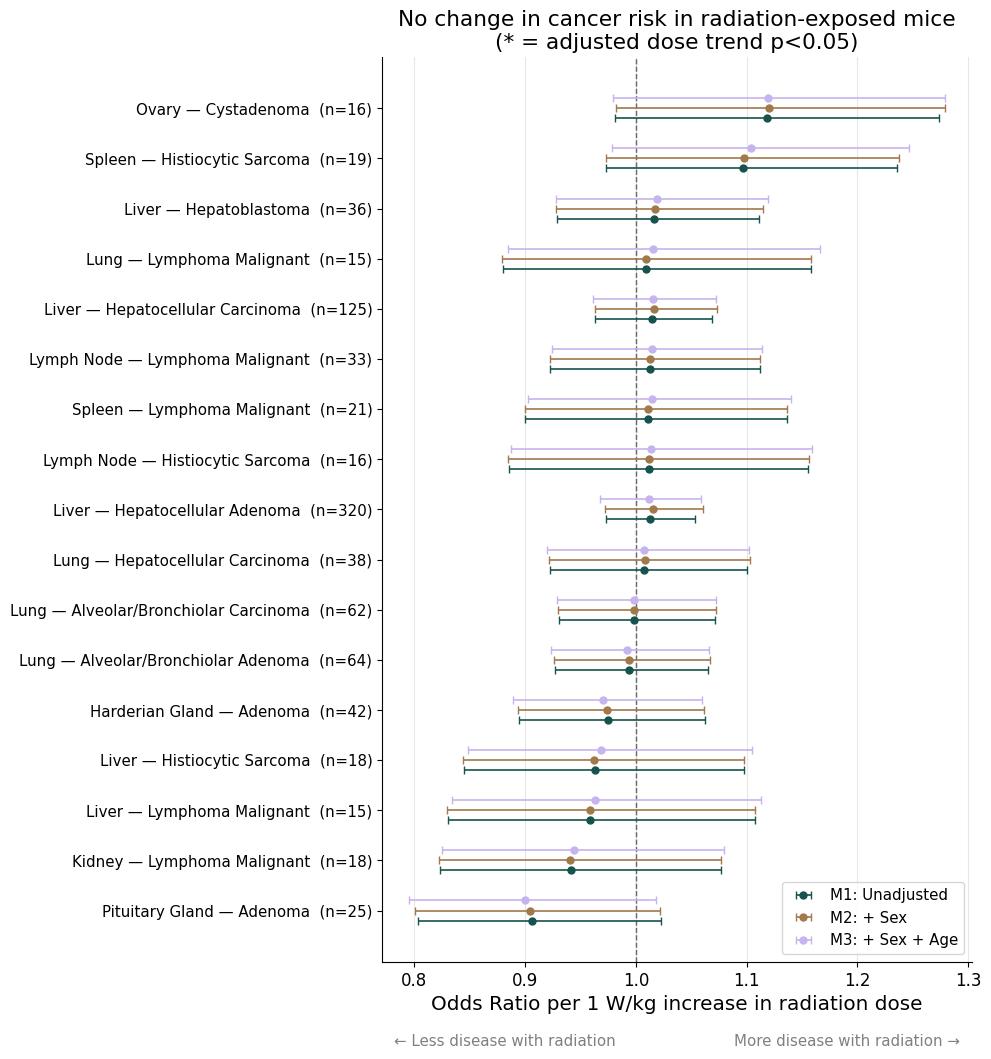

In [10]:
plot_forest(results_df, "Neoplastic", "No change in cancer risk in radiation-exposed mice")

## 10. Interpretation

**Key finding: No neoplastic pathologies show a significant dose-response relationship in any of the three models.**

The concern about survival confounding — that irradiated mice live longer and thus accumulate more neoplasms — turns out to be moot for this dataset, because there is no significant unadjusted dose effect on neoplasm risk in the first place. The M1 → M3 comparison would reveal confounding if a pathology were significant in M1 (unadjusted) but not in M3 (age-adjusted), but this pattern does not appear for any neoplastic finding.

Five **non-neoplastic** pathologies show significant dose effects, and all five persist after adjusting for sex and age (M3), suggesting they are real (not confounded by survival). Interestingly, 3 of the 5 show **decreased** risk with increasing dose (OR < 1), while 2 show increased risk.

**Bottom line for CDMA-exposed B6C3F1 mice:** There is no statistical evidence that radiation dose increases the risk of any specific neoplasm, whether or not you correct for the differential survival between groups.

## 8. Forest Plot — Non-Neoplastic Pathologies

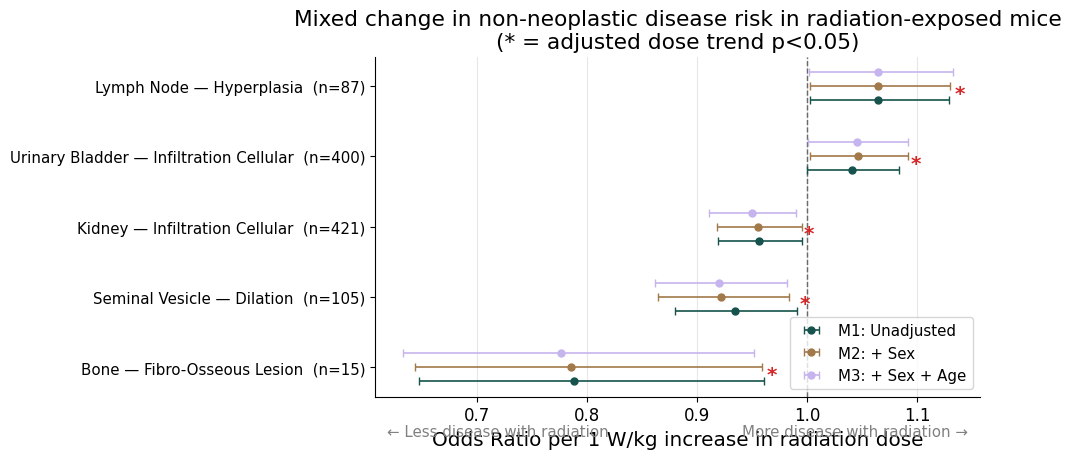

In [11]:
plot_forest(results_df, "Non-Neoplastic", "Mixed change in non-neoplastic disease risk in radiation-exposed mice", significant_only=True)

## 9. Prevalence by Dose Group — Barplots

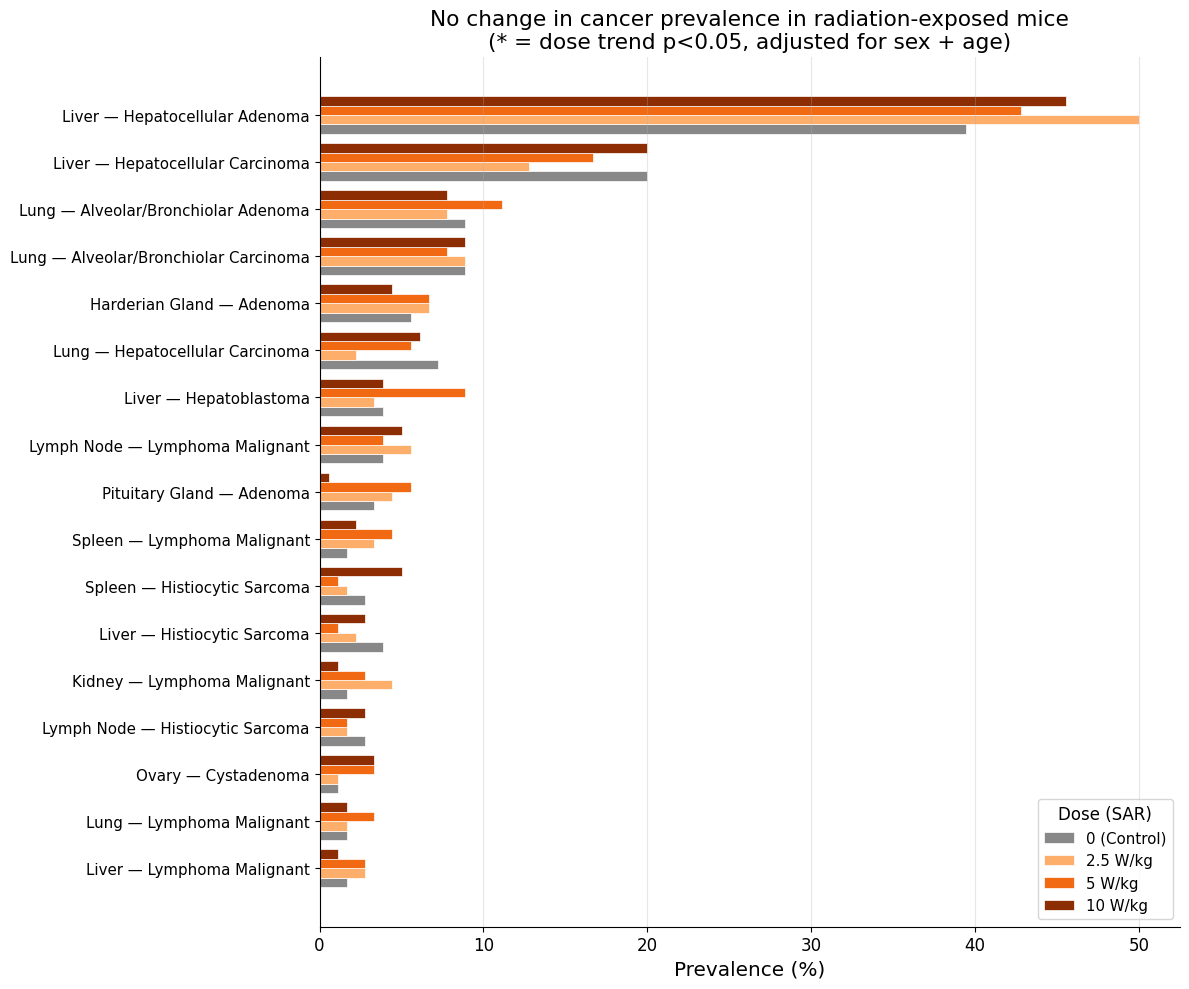

In [12]:
plot_prevalence_bars(results_df, "Neoplastic", "No change in cancer prevalence in radiation-exposed mice", DOSE_VALS, DOSE_COLORS, DOSE_BAR_LABELS)

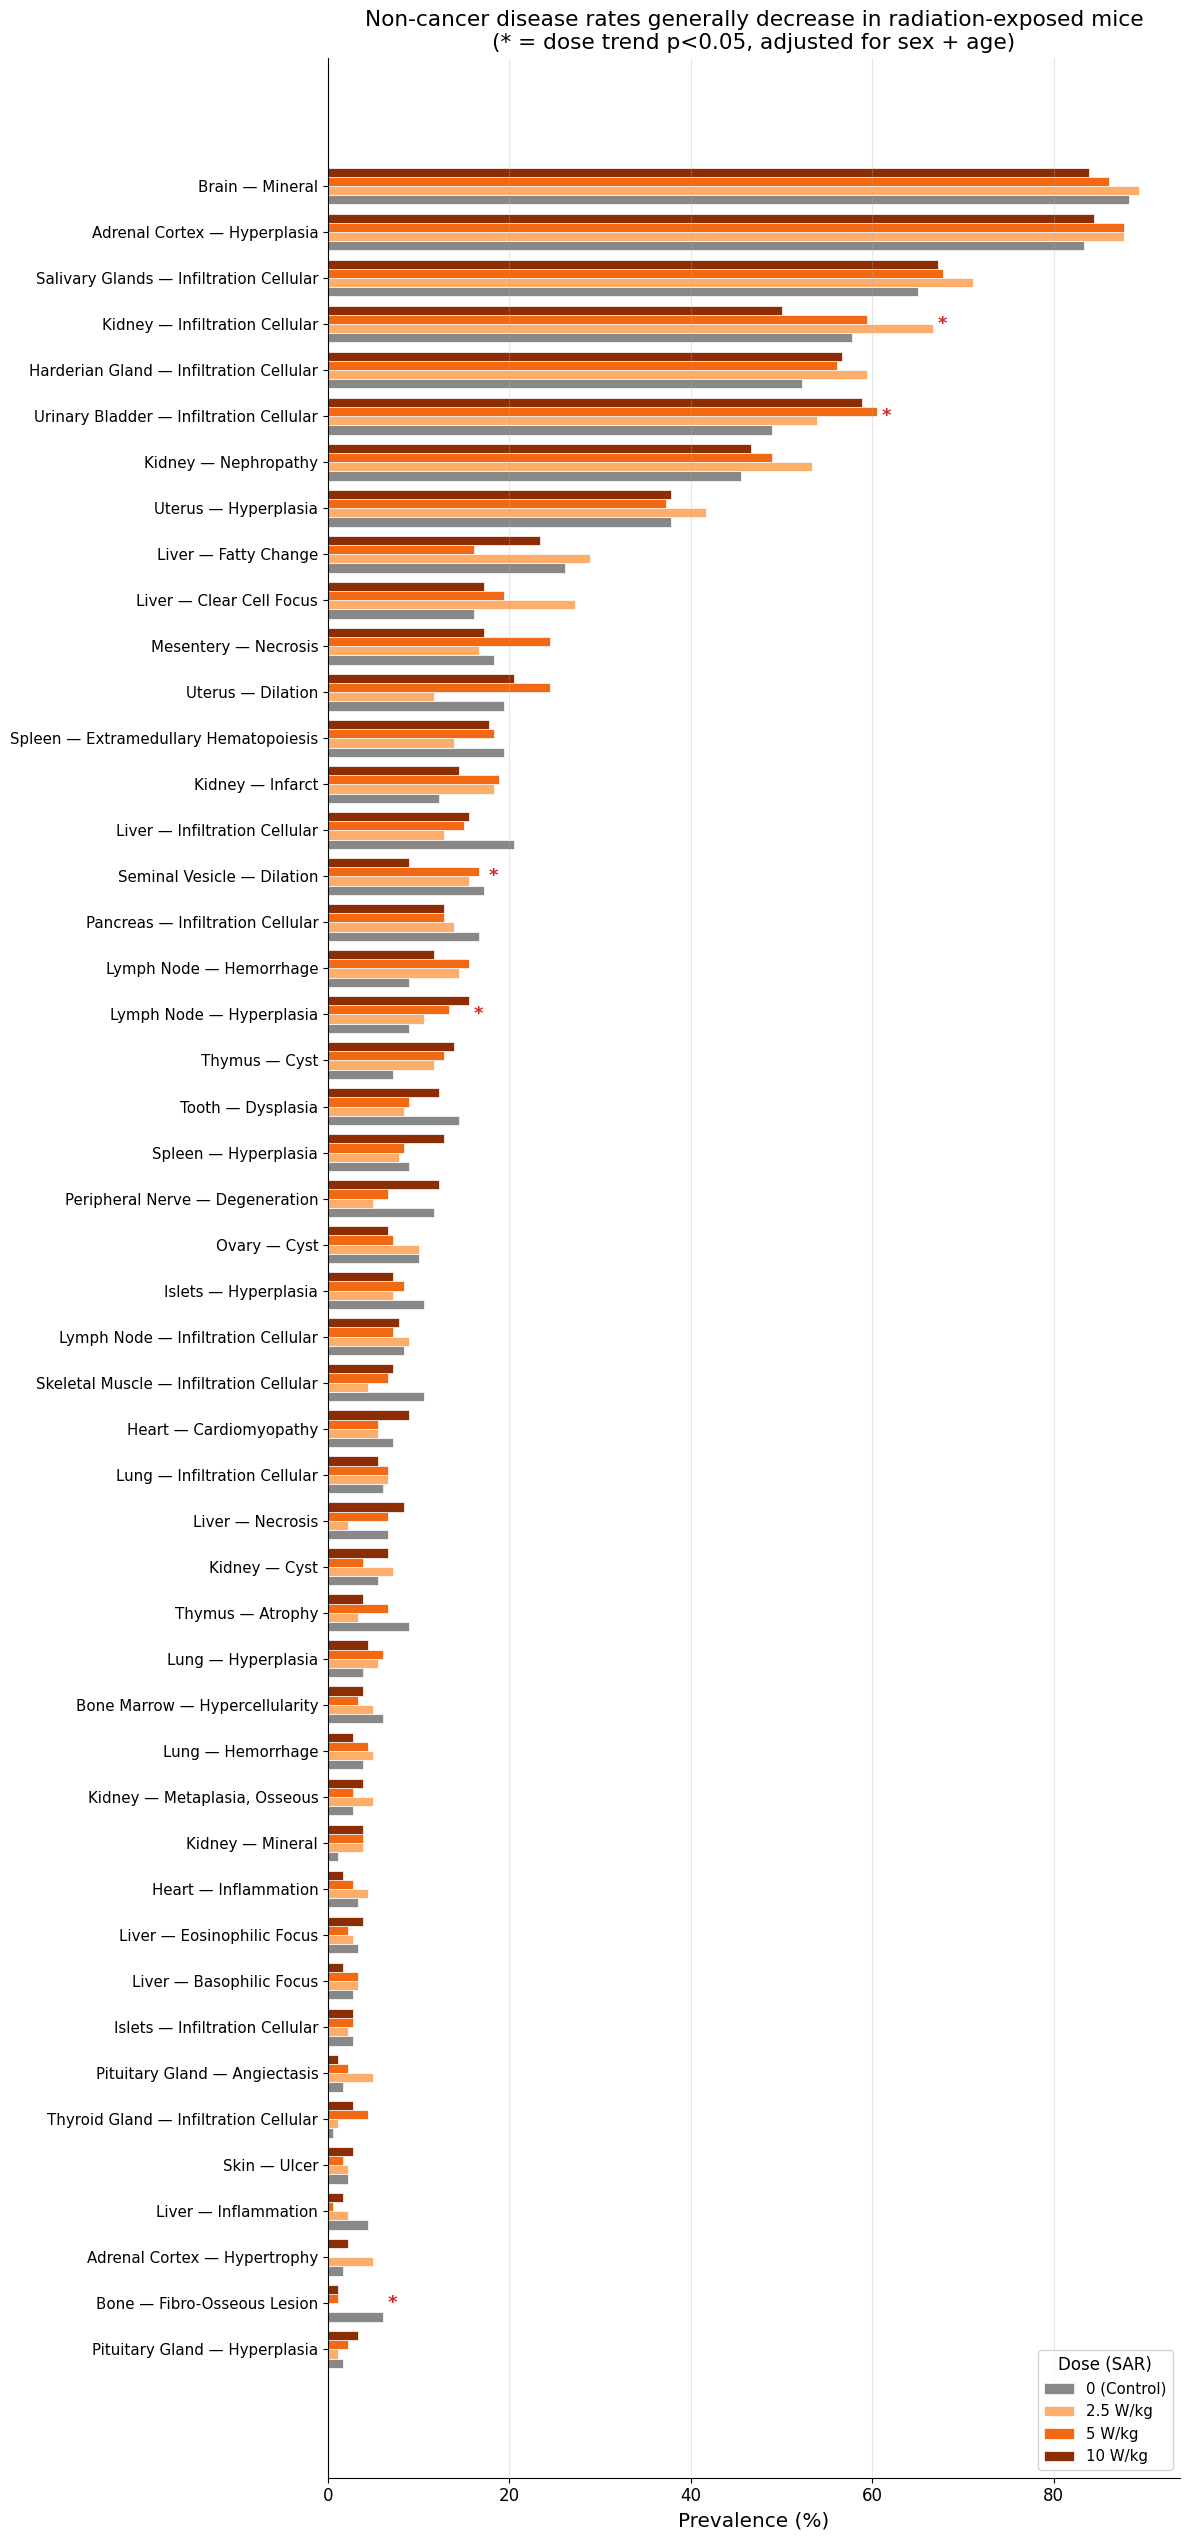

In [13]:
plot_prevalence_bars(results_df, "Non-Neoplastic", "Non-cancer disease rates generally decrease in radiation-exposed mice", DOSE_VALS, DOSE_COLORS, DOSE_BAR_LABELS)